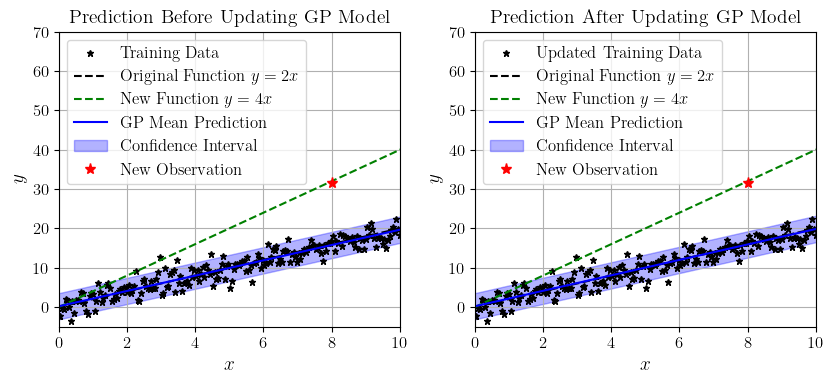

/tmp/ipykernel_3650230/2811312597.py:248: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(frame_filename)
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (635, 576) to (640, 576) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[swscaler @ 0x6a38640] Warning: data is not aligned! This can lead to a speed loss


PDF has been saved as 'MotivationFailureDetection.pdf'.
MP4 video has been created and saved as 'GP_Convergence.mp4'.


In [3]:
# Import necessary libraries
import torch
import gpytorch
from matplotlib import pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import imageio
import shutil

# Set random seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Configure Matplotlib with your specified settings
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 12  # Adjust as needed
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

# Define the original and new underlying functions
def original_function(x):
    return 2 * x

def new_function(x):
    return 4 * x

# Generate training data from the original underlying model y = 2x + noise
train_x = torch.linspace(0, 10, 200)
train_y = original_function(train_x) + torch.randn(train_x.size()) * 2  # Adding noise

# Define GP model with a linear kernel
class LinearGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(LinearGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.LinearMean(input_size=1)
        self.covar_module = gpytorch.kernels.LinearKernel()
    
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = LinearGPModel(train_x.unsqueeze(-1), train_y, likelihood)

# Training the model
model.train()
likelihood.train()

# Use the Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

# Loss function (marginal log likelihood)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

training_iterations = 50
for i in range(training_iterations):
    optimizer.zero_grad()
    output = model(train_x.unsqueeze(-1))
    loss = -mll(output, train_y)
    loss.backward()
    optimizer.step()

# Set into eval mode
model.eval()
likelihood.eval()

# Define test points for plotting
test_x = torch.linspace(0, 12, 50)

# First new observation where the underlying function has changed
test_point1_x = torch.tensor([8.0])
test_point1_y = new_function(test_point1_x) + torch.randn(1) * 2  # y = 4x + noise

# Make predictions with the original model
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred1 = likelihood(model(test_x.unsqueeze(-1)))
    test_point1_pred = likelihood(model(test_point1_x.unsqueeze(-1)))

# Create the first plot
fig, axs = plt.subplots(1, 2, figsize=(8.5, 4))  # Adjusted figsize for better fit

# First plot: Before adding the new point
axs[0].plot(train_x.numpy(), train_y.numpy(), 'k*', markersize=5, label=r'Training Data')
axs[0].plot(test_x.numpy(), original_function(test_x.numpy()), 'k--', label=r'Original Function $y=2x$')
axs[0].plot(test_x.numpy(), new_function(test_x.numpy()), 'g--', label=r'New Function $y=4x$')
axs[0].plot(test_x.numpy(), observed_pred1.mean.numpy(), 'b', linewidth=1.5, label='GP Mean Prediction')
axs[0].fill_between(
    test_x.numpy(),
    observed_pred1.mean.numpy() - 2 * observed_pred1.stddev.numpy(),
    observed_pred1.mean.numpy() + 2 * observed_pred1.stddev.numpy(),
    alpha=0.3,
    color='blue',
    label='Confidence Interval'
)
axs[0].plot(test_point1_x.numpy(), test_point1_y.numpy(), 'r*', markersize=8, label='New Observation')
axs[0].legend(loc='upper left')
axs[0].set_xlabel(r'$x$')
axs[0].set_ylabel(r'$y$')
axs[0].set_xlim(0, 10)
axs[0].set_ylim(-5, 70)
axs[0].set_title('Prediction Before Updating GP Model')
axs[0].grid(True)

# Update the training data with the new observation
train_x_updated = torch.cat([train_x, test_point1_x])
train_y_updated = torch.cat([train_y, test_point1_y])

# Update the model's training data without retraining hyperparameters
model.set_train_data(inputs=train_x_updated.unsqueeze(-1), targets=train_y_updated, strict=False)

# Make predictions with the updated model
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred2 = likelihood(model(test_x.unsqueeze(-1)))
    test_point1_pred_updated = likelihood(model(test_point1_x.unsqueeze(-1)))

# Second plot: After adding the new point
axs[1].plot(train_x_updated.numpy(), train_y_updated.numpy(), 'k*', markersize=5, label='Updated Training Data')
axs[1].plot(test_x.numpy(), original_function(test_x.numpy()), 'k--', label=r'Original Function $y=2x$')
axs[1].plot(test_x.numpy(), new_function(test_x.numpy()), 'g--', label=r'New Function $y=4x$')
axs[1].plot(test_x.numpy(), observed_pred2.mean.numpy(), 'b', linewidth=1.5, label='GP Mean Prediction')
axs[1].fill_between(
    test_x.numpy(),
    observed_pred2.mean.numpy() - 2 * observed_pred2.stddev.numpy(),
    observed_pred2.mean.numpy() + 2 * observed_pred2.stddev.numpy(),
    alpha=0.3,
    color='blue',
    label='Confidence Interval'
)
axs[1].plot(test_point1_x.numpy(), test_point1_y.numpy(), 'r*', markersize=8, label='New Observation')
axs[1].legend(loc='upper left')
axs[1].set_xlabel(r'$x$')
axs[1].set_ylabel(r'$y$')
axs[1].set_xlim(0, 10)
axs[1].set_ylim(-5, 70)
axs[1].set_title('Prediction After Updating GP Model')
axs[1].grid(True)

plt.tight_layout()

# Save the figure as a high-resolution PDF
plt.savefig('MotivationFailureDetection.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()

# -----------------------------------------------
# Now, create the MP4 video showing gradual convergence
# without retraining the model hyperparameters
# -----------------------------------------------

# Prepare to save frames for the video
frames_dir = 'video_frames'
if not os.path.exists(frames_dir):
    os.makedirs(frames_dir)

# Number of new points to add
num_new_points = 300
new_points_x = torch.linspace(0, 10, num_new_points)
new_points_y = new_function(new_points_x) + torch.randn(new_points_x.size()) * 2  # Adding noise

# Shuffle the new_points_x and new_points_y together
shuffle_indices = torch.randperm(num_new_points)
new_points_x = new_points_x[shuffle_indices]
new_points_y = new_points_y[shuffle_indices]

# Initialize updated training data
train_x_video = train_x.clone()
train_y_video = train_y.clone()

# Copy the trained model to avoid altering the original model
import copy
model_video = copy.deepcopy(model)

# Loop over new data points to create frames
for idx in range(num_new_points + 1):
    # Create the figure
    fig, ax = plt.subplots(figsize=(4.4, 4))
    
    # Update training data with new observations up to current index
    if idx > 0:
        current_point_x = new_points_x[idx - 1].unsqueeze(0)
        current_point_y = new_points_y[idx - 1].unsqueeze(0)
        train_x_video = torch.cat([train_x_video, current_point_x])
        train_y_video = torch.cat([train_y_video, current_point_y])
    
    # Update the model's training data without retraining hyperparameters
    model_video.set_train_data(inputs=train_x_video.unsqueeze(-1), targets=train_y_video, strict=False)
    
    # Set into eval mode
    model_video.eval()
    likelihood.eval()
    
    # Make predictions with the updated model
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        observed_pred = likelihood(model_video(test_x.unsqueeze(-1)))
    
    # Plot training data
    ax.plot(train_x.numpy(), train_y.numpy(), 'k*', markersize=5, label='Original Training Data')
    if idx > 0:
        ax.plot(new_points_x[:idx].numpy(), new_points_y[:idx].numpy(), 'r*', markersize=5, label='New Observations')
    
    # Plot true functions
    ax.plot(test_x.numpy(), original_function(test_x.numpy()), 'k--', label=r'Original Function $y=2x$')
    ax.plot(test_x.numpy(), new_function(test_x.numpy()), 'g--', label=r'New Function $y=4x$')
    
    # Plot GP mean and confidence intervals
    ax.plot(test_x.numpy(), observed_pred.mean.numpy(), 'b', linewidth=1.5, label='GP Mean Prediction')
    ax.fill_between(
        test_x.numpy(),
        observed_pred.mean.numpy() - 2 * observed_pred.stddev.numpy(),
        observed_pred.mean.numpy() + 2 * observed_pred.stddev.numpy(),
        alpha=0.3,
        color='blue',
        label='Confidence Interval'
    )
    
    #ax.legend(loc='upper left')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(0, 10)
    ax.set_ylim(-5, 70)
    ax.set_title(f'Prediction with {idx} New Data Points')
    ax.grid(True)
    
    plt.tight_layout()

    if idx == num_new_points:
        plt.savefig('MotivationFailureDetectionManyPoints.pdf', format='pdf', bbox_inches='tight', dpi=300)
    
    # Save the frame
    frame_filename = os.path.join(frames_dir, f'frame_{idx:04d}.png')
    plt.savefig(frame_filename, format='png', bbox_inches='tight', dpi=150)
    plt.close(fig)

# Create the MP4 video using imageio
# Collect all frame filenames
frame_filenames = [os.path.join(frames_dir, f'frame_{idx:04d}.png') for idx in range(num_new_points + 1)]

# Create the video writer
with imageio.get_writer('GP_Convergence.mp4', fps=80) as writer:
    for frame_filename in frame_filenames:
        image = imageio.imread(frame_filename)
        writer.append_data(image)

# Cleanup: Remove the frames directory
shutil.rmtree(frames_dir)

print("PDF has been saved as 'MotivationFailureDetection.pdf'.")
print("MP4 video has been created and saved as 'GP_Convergence.mp4'.")
